In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [55]:
import yfinance as yf

data = yf.download("BABA", start="2021-01-01", end="2026-09-03")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            BABA        BABA        BABA        BABA      BABA
Date                                                                
2021-01-04  214.418808  216.799670  211.774439  213.148381  24897900
2021-01-05  226.229004  226.567783  214.672881  215.548067  35823800
2021-01-06  214.192947  224.252800  212.546106  221.100269  37146100
2021-01-07  213.524780  216.394993  207.116216  215.792720  49361800
2021-01-08  222.267181  224.535121  213.320592  214.447038  34884900


In [56]:
# data["Date"] = pd.to_datetime(data["Date"])
# print(data.head(2))

# data.set_index("Date", inplace = True)
# print(data.head(2))

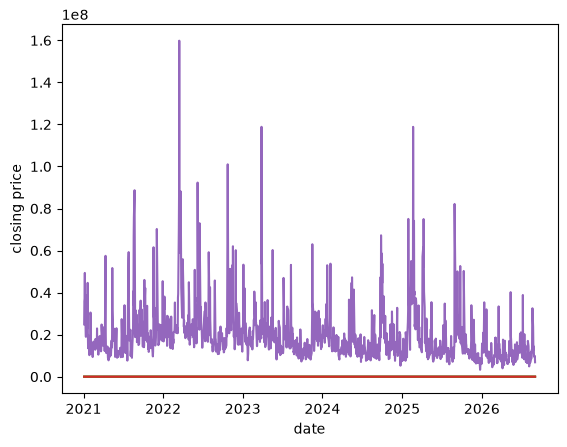

In [57]:
plt.plot(data)
plt.ylabel("closing price")
plt.xlabel("date")
plt.show()

In [58]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data["Close"])
print(result)
print(f"pvlaue is {result[1]} and AD statics is {result[0]}")

# pvalue >0.05, this is non stationary 


(np.float64(-2.4855338487665133), np.float64(0.11903388773806822), 4, 1418, {'1%': np.float64(-3.4349700122033804), '5%': np.float64(-2.8635804131233096), '10%': np.float64(-2.567856305330816)}, np.float64(7478.597513301538))
pvlaue is 0.11903388773806822 and AD statics is -2.4855338487665133


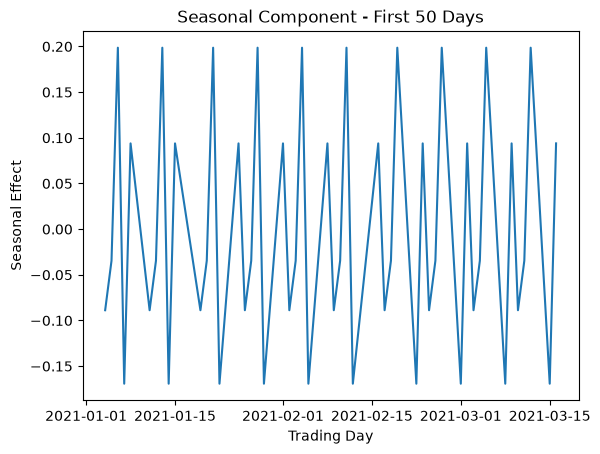

In [59]:
from statsmodels.tsa.seasonal import seasonal_decompose
close = data["Close"]
results = seasonal_decompose(close, period = 5)
print(results)
plt.plot(results.seasonal[:50])
plt.title("Seasonal Component - First 50 Days")
plt.xlabel("Trading Day")
plt.ylabel("Seasonal Effect")
plt.show()

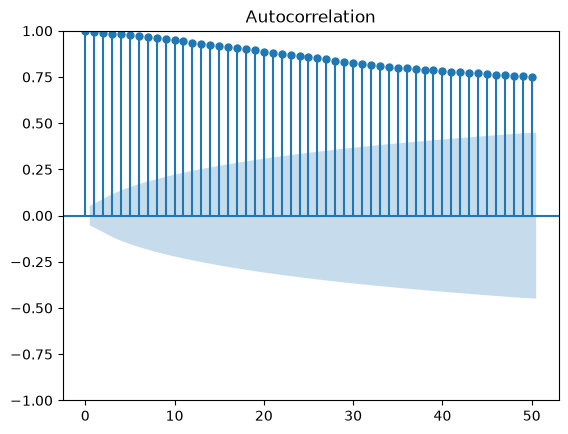

In [60]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(close, lags= 50 )
plt.show()

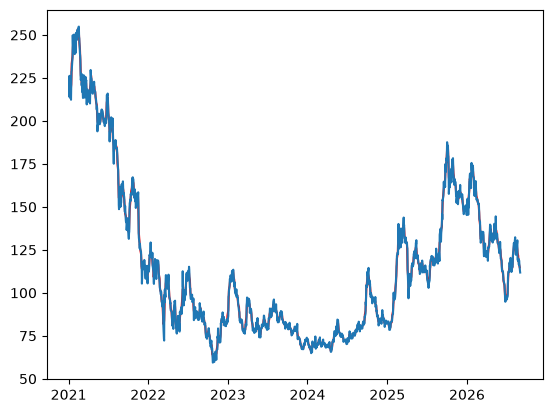

In [61]:
plt.plot(results.trend, c= "r")
plt.plot(close)
plt.show()

In [62]:
split= int(0.8*len(close))
x_train= close[:split]
x_test= close[split:]

print(x_train[:5])
print(x_test[:3])

Ticker            BABA
Date                  
2021-01-04  214.418808
2021-01-05  226.229004
2021-01-06  214.192947
2021-01-07  213.524780
2021-01-08  222.267181
Ticker            BABA
Date                  
2025-07-17  116.232529
2025-07-18  119.135864
2025-07-21  119.175491


In [63]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler(feature_range=(0, 1))

x_train_norm= scale.fit_transform(x_train)
print(x_train_norm[:4])
print(x_train_norm.shape)
x_test_norm = scale.transform(x_test)
print(x_test[:2])

[[0.7930471 ]
 [0.85347654]
 [0.79189143]
 [0.78847261]]
(1138, 1)
Ticker            BABA
Date                  
2025-07-17  116.232529
2025-07-18  119.135864


In [64]:
# converting the shape of x_train to 3d  and crearing y_train for every 60 days consecutive day 

x_train_LSTM=[]
y_train_LSTM=[]

for i in range (60, len(x_train_norm)):
    x_train_LSTM.append(x_train_norm[i-60:i,0])
    y_train_LSTM.append(x_train_norm[i,0])


print(x_train_LSTM[:1])
print(y_train_LSTM[:1])


[array([0.7930471 , 0.85347654, 0.79189143, 0.78847261, 0.83320501,
       0.79073577, 0.78221303, 0.82891948, 0.86589944, 0.86821069,
       0.90764634, 0.97428735, 0.94785251, 0.94120763, 0.95449738,
       0.97635797, 0.94905634, 0.95151203, 0.91814335, 0.97043529,
       0.92136949, 0.96436824, 0.98136554, 0.97515414, 0.96032365,
       0.97910254, 0.98536228, 0.99085126, 0.98565116, 0.999374  ,
       1.        , 0.96956866, 0.96513868, 0.91896189, 0.91294302,
       0.90133858, 0.85241715, 0.84076462, 0.85968803, 0.82468228,
       0.83359024, 0.80580712, 0.82213024, 0.78746154, 0.84259438,
       0.82410437, 0.8554025 , 0.81240374, 0.80474772, 0.78861705,
       0.81948194, 0.83436052, 0.85053929, 0.83768292, 0.8403313 ,
       0.80142524, 0.76834559, 0.79020611, 0.81235557, 0.79978816])]
[np.float64(0.7876540698948242)]


In [65]:
x_train_LSTM=np.array(x_train_LSTM)
y_train_LSTM=np.array(y_train_LSTM)

print(x_train_LSTM[:2])
print(y_train_LSTM[:2])


print(x_train_LSTM.shape)
print(y_train_LSTM.shape)


x_train_LSTM = x_train_LSTM.reshape(
    x_train_LSTM.shape[0],
    x_train_LSTM.shape[1],1)


[[0.7930471  0.85347654 0.79189143 0.78847261 0.83320501 0.79073577
  0.78221303 0.82891948 0.86589944 0.86821069 0.90764634 0.97428735
  0.94785251 0.94120763 0.95449738 0.97635797 0.94905634 0.95151203
  0.91814335 0.97043529 0.92136949 0.96436824 0.98136554 0.97515414
  0.96032365 0.97910254 0.98536228 0.99085126 0.98565116 0.999374
  1.         0.96956866 0.96513868 0.91896189 0.91294302 0.90133858
  0.85241715 0.84076462 0.85968803 0.82468228 0.83359024 0.80580712
  0.82213024 0.78746154 0.84259438 0.82410437 0.8554025  0.81240374
  0.80474772 0.78861705 0.81948194 0.83436052 0.85053929 0.83768292
  0.8403313  0.80142524 0.76834559 0.79020611 0.81235557 0.79978816]
 [0.85347654 0.79189143 0.78847261 0.83320501 0.79073577 0.78221303
  0.82891948 0.86589944 0.86821069 0.90764634 0.97428735 0.94785251
  0.94120763 0.95449738 0.97635797 0.94905634 0.95151203 0.91814335
  0.97043529 0.92136949 0.96436824 0.98136554 0.97515414 0.96032365
  0.97910254 0.98536228 0.99085126 0.98565116 0.9

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


LSTM_model = Sequential()

LSTM_model.add(
            LSTM(
                120,
                activation="relu", 
                input_shape=(x_train_LSTM.shape[1], x_train_LSTM.shape[2])
            )
)
LSTM_model.add(Dropout(0.1)),
LSTM_model.add(Dense(64, activation="relu"))
LSTM_model.add(Dropout(0.1))
LSTM_model.add(Dense(1))

c:\Users\e_bab\Documents\4geeks\python-hello\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
from tensorflow.keras.optimizers import Adam

LSTM_model.compile(optimizer=Adam (learning_rate = 0.001), loss= "mse")

In [68]:
x_test_LSTM=[]
y_test_LSTM=[]

for i in range (60, len(x_test_norm)):
    x_test_LSTM.append(x_test_norm[i-60:i,0])
    y_test_LSTM.append(x_test_norm[i,0])

x_test_LSTM=np.array(x_test_LSTM)
y_test_LSTM=np.array(y_test_LSTM)

x_test_LSTM = x_test_LSTM.reshape(
    x_test_LSTM.shape[0],
    x_test_LSTM.shape[1],1)

print(x_test_LSTM.shape)
print(y_test_LSTM.shape)


(225, 60, 1)
(225,)


In [69]:
LSTM_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 120)            │        58,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history = LSTM_model.fit(x_train_LSTM, y_train_LSTM, epochs = 10, batch_size = 32)



Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0311
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0028
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0023
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0022
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0019
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015


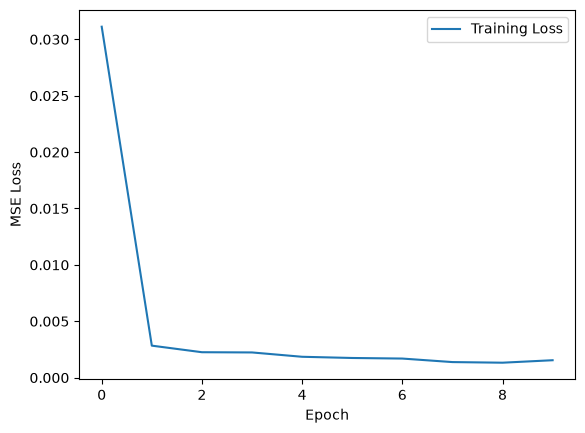

In [71]:
plt.plot(history.history["loss"], label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [72]:
test_loss = LSTM_model.evaluate(x_test_LSTM, y_test_LSTM)
y_pred= LSTM_model.predict(x_test_LSTM)
print(y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3693e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[0.5996342 ]
 [0.5675139 ]
 [0.5507269 ]
 [0.5322031 ]
 [0.52223057]
 [0.5145842 ]
 [0.5125902 ]
 [0.5208541 ]
 [0.52038455]
 [0.5196439 ]
 [0.52734953]
 [0.53755224]
 [0.55173033]
 [0.56053483]
 [0.5713799 ]
 [0.5721501 ]
 [0.56706506]
 [0.55810344]
 [0.5453595 ]
 [0.5351068 ]
 [0.53051245]
 [0.5256503 ]
 [0.52170616]
 [0.512306  ]
 [0.50112605]
 [0.49493074]
 [0.48256928]
 [0.47817314]
 [0.47815764]
 [0.47806185]
 [0.4713061 ]
 [0.46556425]
 [0.4714574 ]
 [0.47216153]
 [0.47383046]
 [0.47494882]
 [0.48497638]
 [0.48945776]
 [0.48890328]
 [0.48706007]
 [0.48622292]
 [0.48500848]
 [0.4809695 ]
 [0.4812459 ]
 [0.47903895]
 [0.47564816]
 [0.465496  ]
 [0.45596662]
 [0.4453823 ]
 [0.43734598]
 [0.43462625]
 [0.43481898]
 [0.43619356]
 [0.43645096]
 [0.43990386]
 [0.43816483]
 [0.43522495]
 [0.43169457]
 [0.44076002]
 [0.4493962 ]
 [0.4497059 ]
 [0.44410086]
 [0.44900352]
 [0.44845316]
 [0.466610

In [73]:
y_pred_original = scale.inverse_transform(y_pred)
print(y_pred_original)

[[176.61862 ]
 [170.34111 ]
 [167.0603  ]
 [163.44005 ]
 [161.49104 ]
 [159.99664 ]
 [159.60695 ]
 [161.22203 ]
 [161.13025 ]
 [160.9855  ]
 [162.49147 ]
 [164.48547 ]
 [167.25641 ]
 [168.97714 ]
 [171.09668 ]
 [171.24721 ]
 [170.25339 ]
 [168.50195 ]
 [166.0113  ]
 [164.00754 ]
 [163.10963 ]
 [162.1594  ]
 [161.38855 ]
 [159.55139 ]
 [157.36642 ]
 [156.15562 ]
 [153.73973 ]
 [152.88055 ]
 [152.87752 ]
 [152.85881 ]
 [151.53847 ]
 [150.4163  ]
 [151.56804 ]
 [151.70566 ]
 [152.03183 ]
 [152.2504  ]
 [154.21016 ]
 [155.08598 ]
 [154.97763 ]
 [154.6174  ]
 [154.45378 ]
 [154.21643 ]
 [153.42706 ]
 [153.48108 ]
 [153.04976 ]
 [152.38708 ]
 [150.40297 ]
 [148.54056 ]
 [146.47198 ]
 [144.90138 ]
 [144.36984 ]
 [144.40752 ]
 [144.67615 ]
 [144.72647 ]
 [145.40129 ]
 [145.06142 ]
 [144.48686 ]
 [143.79689 ]
 [145.56862 ]
 [147.25645 ]
 [147.31699 ]
 [146.22154 ]
 [147.1797  ]
 [147.07214 ]
 [150.62086 ]
 [153.80814 ]
 [157.08972 ]
 [160.0113  ]
 [161.02045 ]
 [160.82974 ]
 [162.02774 ]
 [164.

In [74]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test_LSTM, y_pred)
mse = mean_squared_error(y_test_LSTM, y_pred)

print("R²:", r2)
print("MSE:", mse)

R²: 0.9246628180673407
MSE: 0.0008369255235255024


In [75]:
LSTM_model.save("lstm_model.keras")

from pickle import dump
dump(scale, open("scale_min_max.sav", "wb"))